In [15]:
! pip3 install keras
! pip3 install tensorflow

In [47]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [17]:
df=pd.read_csv('Churn_Modelling.csv')

In [18]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [20]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [21]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [23]:
df=pd.get_dummies(df,drop_first=True,columns=['Geography','Gender'])

In [25]:
df['Geography_Germany']=df['Geography_Germany'].astype(int)
df['Geography_Spain']=df['Geography_Spain'].astype(int)
df['Gender_Male']=df['Gender_Male'].astype(int)

In [26]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [28]:
X=df.drop('Exited',axis=1)
y=df['Exited']


In [29]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [32]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2)

In [33]:
print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [34]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [35]:
X_train

array([[-8.13850061e-01, -8.45173805e-01,  3.44546855e-01, ...,
        -5.75810666e-01, -5.76580468e-01,  9.13938358e-01],
       [-1.11383880e+00,  2.39089758e+00, -3.47401140e-01, ...,
        -5.75810666e-01, -5.76580468e-01,  9.13938358e-01],
       [-3.06972531e-01, -1.13070951e+00, -3.47401140e-01, ...,
        -5.75810666e-01, -5.76580468e-01,  9.13938358e-01],
       ...,
       [ 2.61971634e-01, -8.45173805e-01, -1.42714274e-03, ...,
        -5.75810666e-01,  1.73436329e+00, -1.09416570e+00],
       [ 4.99893740e-01,  1.14333257e-02, -1.38532313e+00, ...,
        -5.75810666e-01, -5.76580468e-01, -1.09416570e+00],
       [ 1.08952678e+00,  2.01018330e+00, -1.03934914e+00, ...,
        -5.75810666e-01, -5.76580468e-01,  9.13938358e-01]],
      shape=(8000, 11))

In [36]:
X_test

array([[-1.48623862, -0.36928095, -1.38532313, ..., -0.57581067,
        -0.57658047, -1.0941657 ],
       [ 0.18956056, -0.08374524,  1.03649485, ..., -0.57581067,
        -0.57658047, -1.0941657 ],
       [-0.76212786, -1.22588809, -1.38532313, ..., -0.57581067,
        -0.57658047, -1.0941657 ],
       ...,
       [-2.4793048 , -0.94035237, -1.73129713, ..., -0.57581067,
        -0.57658047,  0.91393836],
       [-0.60696127,  3.05714757, -0.34740114, ..., -0.57581067,
        -0.57658047,  0.91393836],
       [ 1.05849347,  0.67768332,  1.03649485, ..., -0.57581067,
        -0.57658047,  0.91393836]], shape=(2000, 11))

In [41]:
model = Sequential()

model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [78]:
history=model.fit(X_train,Y_train,epochs=100,verbose=1,validation_split=0.3,batch_size=50)
# can induce batch_size for training as well as validation too

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8648 - loss: 0.3341 - val_accuracy: 0.8592 - val_loss: 0.3392
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8648 - loss: 0.3342 - val_accuracy: 0.8592 - val_loss: 0.3392
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8637 - loss: 0.3342 - val_accuracy: 0.8592 - val_loss: 0.3392
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8650 - loss: 0.3342 - val_accuracy: 0.8600 - val_loss: 0.3393
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8654 - loss: 0.3342 - val_accuracy: 0.8592 - val_loss: 0.3392
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.3344 - val_accuracy: 0.8612 - val_loss: 0.3391
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8648 - loss: 0.3342 - val_accuracy: 0.8596 - val_loss: 0.3392
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.3342 - val_accu

In [79]:
y_log=model.predict(X_test)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step


array([[0.02080125],
       [0.02898915],
       [0.264377  ],
       ...,
       [0.00419728],
       [0.10574559],
       [0.9202582 ]], shape=(2000, 1), dtype=float32)

In [80]:
Y_pred=np.where(y_log>=0.5,1,0)

In [81]:
Y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(2000, 1))

In [82]:
accuracy_score(Y_test,Y_pred)

0.85

In [83]:
history.history

{'accuracy': [0.8648214340209961,
  0.8648214340209961,
  0.8637499809265137,
  0.8650000095367432,
  0.8653571605682373,
  0.8651785850524902,
  0.8648214340209961,
  0.8651785850524902,
  0.864642858505249,
  0.8641071319580078,
  0.864642858505249,
  0.8660714030265808,
  0.8650000095367432,
  0.8650000095367432,
  0.8651785850524902,
  0.8657143115997314,
  0.8651785850524902,
  0.8650000095367432,
  0.8650000095367432,
  0.8642857074737549,
  0.864464282989502,
  0.8650000095367432,
  0.8658928275108337,
  0.864642858505249,
  0.864464282989502,
  0.8650000095367432,
  0.8648214340209961,
  0.8657143115997314,
  0.864464282989502,
  0.8655357360839844,
  0.8658928275108337,
  0.8653571605682373,
  0.8639285564422607,
  0.8657143115997314,
  0.8653571605682373,
  0.8648214340209961,
  0.8650000095367432,
  0.8641071319580078,
  0.8651785850524902,
  0.8651785850524902,
  0.8642857074737549,
  0.864642858505249,
  0.8651785850524902,
  0.8650000095367432,
  0.8653571605682373,
  0.8

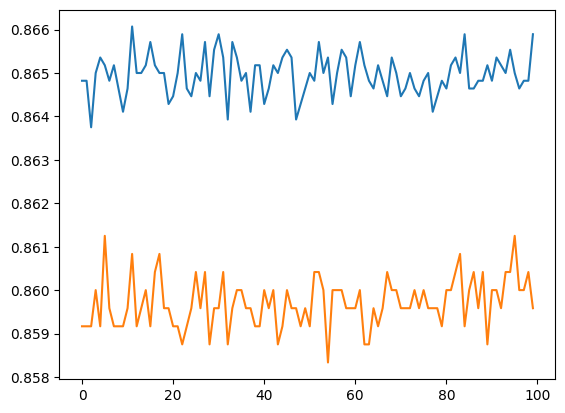

In [86]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()


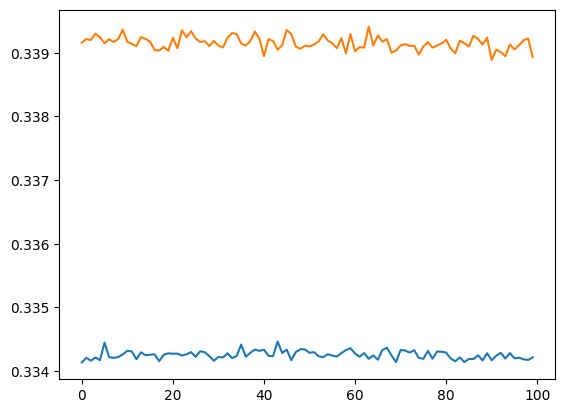

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [100]:
model.layers[0].get_weights()[0].shape

(11, 3)